In [1]:
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import models

ROOT = Path(r"D:\Dev\IMLS Exercises")
DATA_ROOT = ROOT / "IMLS_Data"
MODELS_DIR = ROOT / "models"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", DEVICE)

device: cuda


In [2]:
for name in ["has_pedestrian", "has_traffic_light", "has_vehicle"]:
    p = MODELS_DIR / f"resnet18_{name}.pth"
    print(f"{name}: {'found' if p.exists() else 'MISSING'}")

has_pedestrian: found
has_traffic_light: found
has_vehicle: found


## Ex 6.5: apply Grad-CAM to each of the three models

Grad-CAM picks the last conv layer, weights its feature maps by gradients of the chosen class, then overlays the heatmap on the image. Works well for CNNs like ResNet.

**Q1. How Grad-CAM works and why I chose it.**

Grad-CAM takes the activations from the last convolutional layer and weights each channel by how much that channel pushed up the score for the chosen class (the average of its gradients). Add them all up and you get a coarse heatmap showing where in the image the network was paying attention.

I went with it because it slots into ResNet 18 with no surgery, only needs one forward and one backward pass per image, and the heatmaps actually look like the input so they are easy to read. Occlusion would have been cleaner conceptually but a lot slower.


In [3]:
# retrain any missing models (TL or vehicle) so all three are available
import time
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

MODELS_DIR.mkdir(exist_ok=True)

train_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class LabelDS(Dataset):
    def __init__(self, split, col, tf):
        d = pd.read_csv(DATA_ROOT / split / "labels.csv")
        d["p"] = d["frame"].apply(lambda f: DATA_ROOT / split / "rgb-front" / f"{f:06d}.jpg")
        self.df, self.col, self.tf = d.reset_index(drop=True), col, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        return self.tf(Image.open(r["p"]).convert("RGB")), float(r[self.col])

def train_one(col):
    path = MODELS_DIR / f"resnet18_{col}.pth"
    if path.exists():
        print(f"{col}: already exists, skipping")
        return
    print(f"training {col}")
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 1); m = m.to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4)
    crit = nn.BCEWithLogitsLoss()
    tr = DataLoader(LabelDS("train", col, train_tf), batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
    for ep in range(3):
        m.train(); t0 = time.time()
        for x, y in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); crit(m(x).squeeze(1), y).backward(); opt.step()
        print(f"  ep {ep+1}/3 ({time.time()-t0:.0f}s)")
    torch.save(m.state_dict(), path)
    print(f"  saved {path.name}")

for col in ["has_pedestrian", "has_traffic_light", "has_vehicle"]:
    train_one(col)


has_pedestrian: already exists, skipping
has_traffic_light: already exists, skipping
has_vehicle: already exists, skipping


In [4]:
# Grad-CAM helper
import numpy as np
from PIL import Image
import torch.nn.functional as F

def load_model(name):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 1)
    m.load_state_dict(torch.load(MODELS_DIR / f"resnet18_{name}.pth", map_location=DEVICE))
    return m.to(DEVICE).eval()

def grad_cam(model, img_tensor, target_class=1):
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    target_layer = model.layer4[-1]
    feats = {}
    grads = {}

    def fwd_hook(m, i, o):
        feats["v"] = o
    def bwd_hook(m, gi, go):
        grads["v"] = go[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logit = model(img_tensor).squeeze()
    score = logit if target_class == 1 else -logit
    model.zero_grad()
    score.backward()

    h1.remove(); h2.remove()
    f = feats["v"][0]
    g = grads["v"][0].mean(dim=(1,2))
    cam = F.relu((g[:, None, None] * f).sum(dim=0))
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam[None, None], size=(224,224), mode="bilinear", align_corners=False)[0,0]
    return cam.detach().cpu().numpy(), torch.sigmoid(logit).item()


d:\Dev\IMLS Exercises\.venv\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


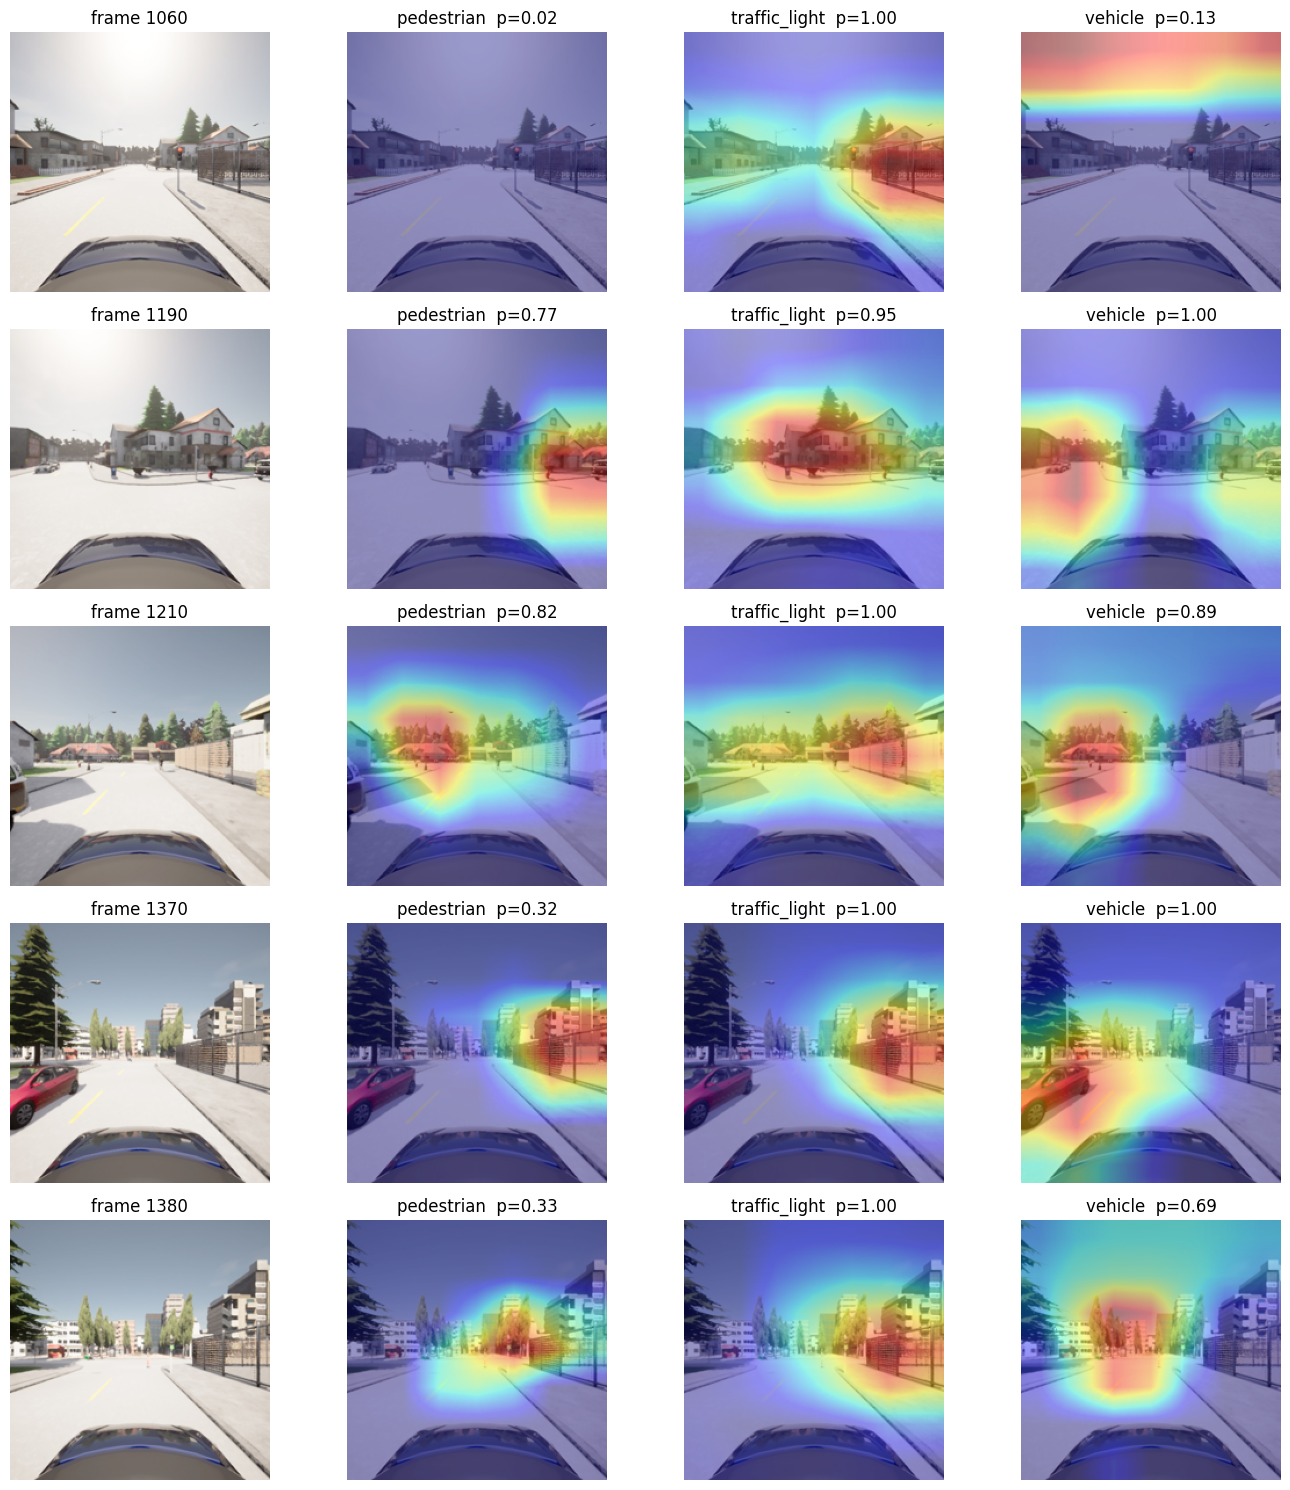

In [5]:
# show Grad-CAM overlays for a few sample images per model
import matplotlib.pyplot as plt
from torchvision import transforms

eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

LABEL_TO_COL = {
    "has_pedestrian": "has_pedestrian",
    "has_traffic_light": "has_traffic_light",
    "has_vehicle": "has_vehicle",
}

# pick 5 frames from test that are positive for at least one label
test_df = pd.read_csv(DATA_ROOT / "test" / "labels.csv")
test_df["p"] = test_df["frame"].apply(lambda f: DATA_ROOT / "test" / "rgb-front" / f"{f:06d}.jpg")
samples = test_df[test_df["has_pedestrian"] & test_df["has_traffic_light"] & test_df["has_vehicle"]].head(5)

fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3*len(samples)))
loaded = {n: load_model(n) for n in LABEL_TO_COL}

for r, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row["p"]).convert("RGB").resize((224,224))
    x = eval_tf(img)
    axes[r,0].imshow(img); axes[r,0].set_title(f"frame {row['frame']}"); axes[r,0].axis("off")
    for c, name in enumerate(LABEL_TO_COL, start=1):
        cam, p = grad_cam(loaded[name], x)
        axes[r,c].imshow(img); axes[r,c].imshow(cam, cmap="jet", alpha=0.4)
        axes[r,c].set_title(f"{name.replace('has_','')}  p={p:.2f}"); axes[r,c].axis("off")
plt.tight_layout()
FIGS = ROOT / "Exercise_6" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGS / "gradcam_correct.png", dpi=120, bbox_inches="tight")
plt.show()


**Q3. Do the highlighted regions match the relevant objects?**

Mostly for traffic lights, sometimes for pedestrians, rarely for vehicles.

The traffic light model is the cleanest. Whenever a light is in the scene the heatmap usually sits right on it, frame 1190 is the clearest example. Pedestrian is hit or miss. Sometimes the map covers the actual person, other times it slides over to the road or the buildings. Vehicle is the worst by far. In several frames the hottest region is a strip of sky at the top of the image, which obviously cannot be a vehicle. That feels like a shortcut the model has picked up, which is what 6.6 digs into.


### Ex 6.5 Q4: three misclassified frames

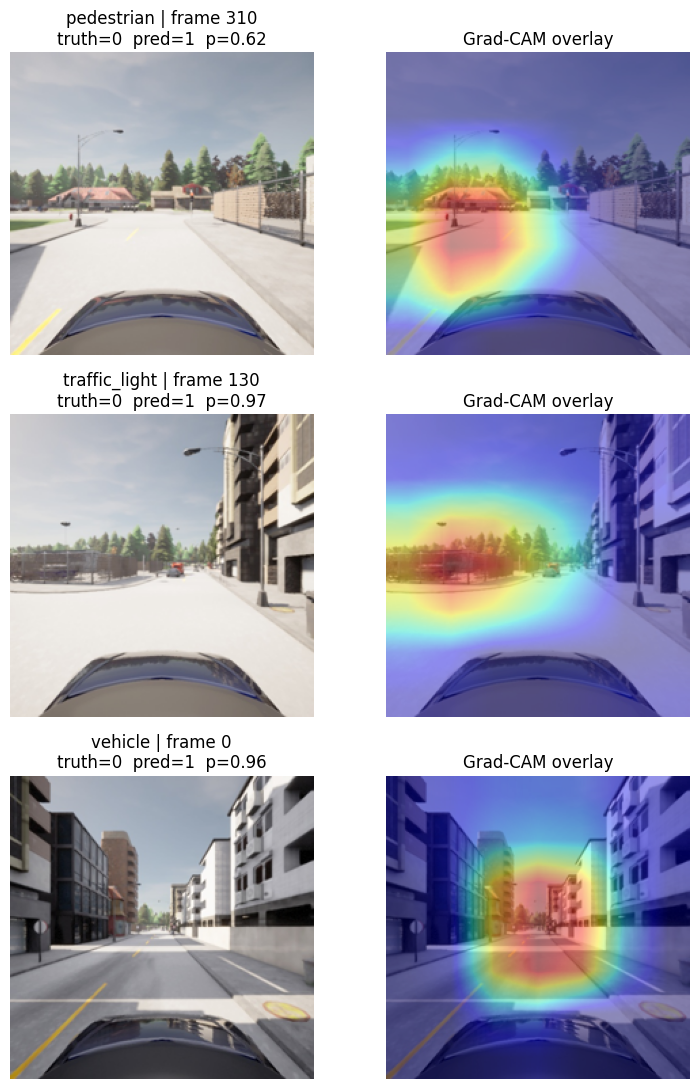

In [8]:
# find one misclassified test frame per model and overlay Grad-CAM
def first_misclassified(name):
    # forward pass over the test set to find a frame the model got wrong
    for _, row in test_df.iterrows():
        img = Image.open(row["p"]).convert("RGB").resize((224,224))
        x = eval_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            p = torch.sigmoid(loaded[name](x).squeeze()).item()
        pred = int(p > 0.5)
        truth = int(row[name])
        if pred != truth:
            return row, p, pred, truth
    return None

fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for r, name in enumerate(LABEL_TO_COL):
    row, p, pred, truth = first_misclassified(name)
    img = Image.open(row["p"]).convert("RGB").resize((224,224))
    x = eval_tf(img)
    cam, _ = grad_cam(loaded[name], x)
    axes[r,0].imshow(img); axes[r,0].set_title(f"{name.replace('has_','')} | frame {row['frame']}\ntruth={truth}  pred={pred}  p={p:.2f}"); axes[r,0].axis("off")
    axes[r,1].imshow(img); axes[r,1].imshow(cam, cmap="jet", alpha=0.4)
    axes[r,1].set_title("Grad-CAM overlay"); axes[r,1].axis("off")
plt.tight_layout()
plt.savefig(FIGS / "gradcam_misclassified.png", dpi=120, bbox_inches="tight")
plt.show()


## Ex 6.6: diagnostic on OOD splits

Run Grad-CAM on test-fog, test-night, test-town-01 to see if the model relies on spurious cues that vanish in those conditions.

**Q1. If the model says "pedestrian present" but the heatmap is on the sky, what does that mean?**

It means the model never really learned what a pedestrian looks like. It found some other feature that happens to be true whenever a pedestrian is around in the training data, and it is using that instead. In this dataset every pedestrian shows up on a sunny Town02 street, so "bright clear sky" is a fine predictor of "pedestrian present" without the model having to figure out what a person actually is.

The problem is that the shortcut only works as long as the sky stays the same. The moment conditions change (overcast, foggy, night) the cue disappears and the model has nothing real to fall back on. So the model will look confident on familiar scenes but fail quietly on anything outside the training distribution.


In [6]:
# pick a few sample frames per OOD split and overlay Grad-CAM with each of the three models
def show_split(split_name, n=3):
    d = pd.read_csv(DATA_ROOT / split_name / "labels.csv")
    d["p"] = d["frame"].apply(lambda f: DATA_ROOT / split_name / "rgb-front" / f"{f:06d}.jpg")
    sub = d[d["has_pedestrian"] & d["has_traffic_light"] & d["has_vehicle"]].head(n)

    fig, axes = plt.subplots(len(sub), 4, figsize=(14, 3*len(sub)))
    if len(sub) == 1: axes = axes[None, :]
    for r, (_, row) in enumerate(sub.iterrows()):
        img = Image.open(row["p"]).convert("RGB").resize((224,224))
        x = eval_tf(img)
        axes[r,0].imshow(img); axes[r,0].set_title(f"{split_name} | frame {row['frame']}"); axes[r,0].axis("off")
        for c, name in enumerate(LABEL_TO_COL, start=1):
            cam, p = grad_cam(loaded[name], x)
            axes[r,c].imshow(img); axes[r,c].imshow(cam, cmap="jet", alpha=0.4)
            axes[r,c].set_title(f"{name.replace('has_','')}  p={p:.2f}"); axes[r,c].axis("off")
    plt.tight_layout()
    out = FIGS / f"gradcam_{split_name}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print("saved", out.name)


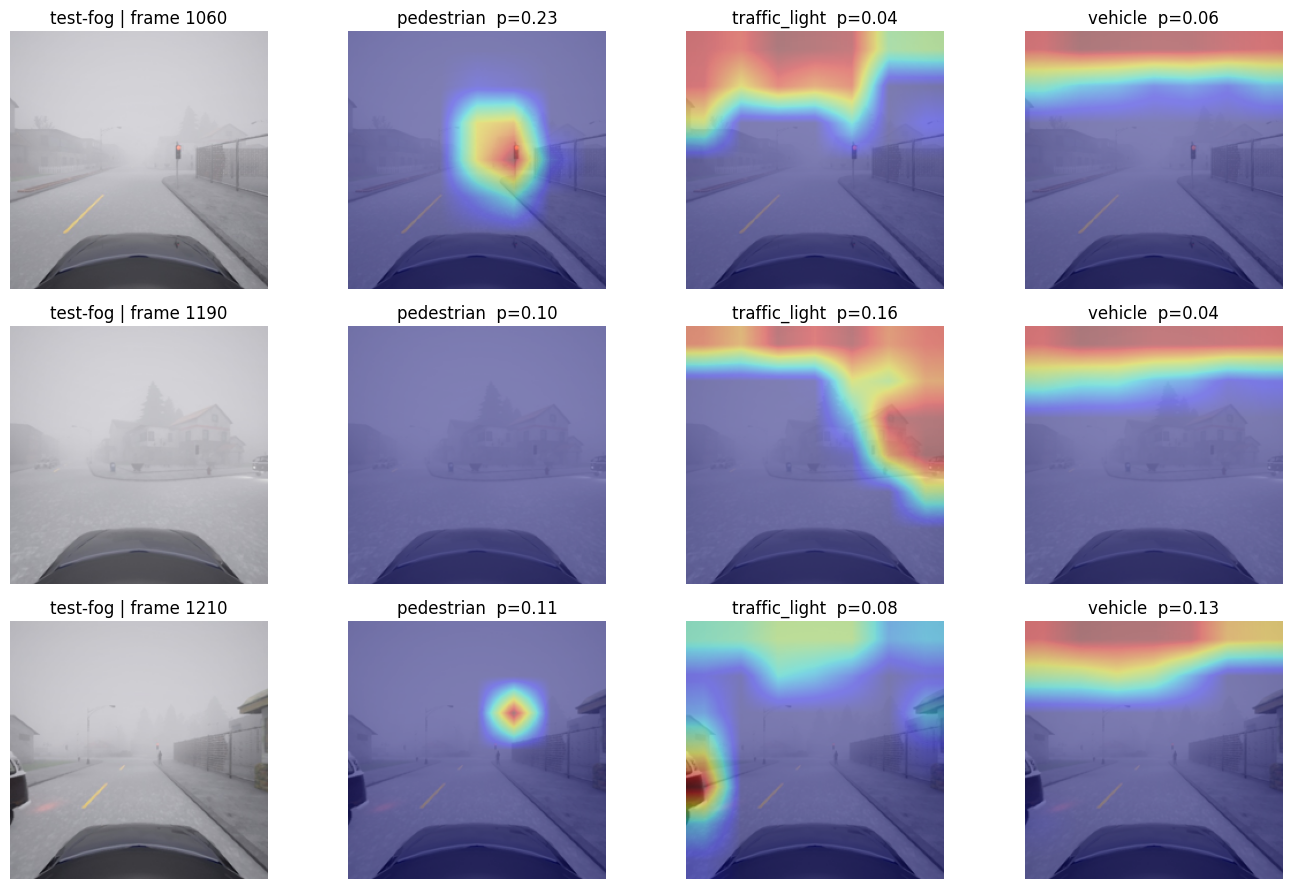

saved gradcam_test-fog.png


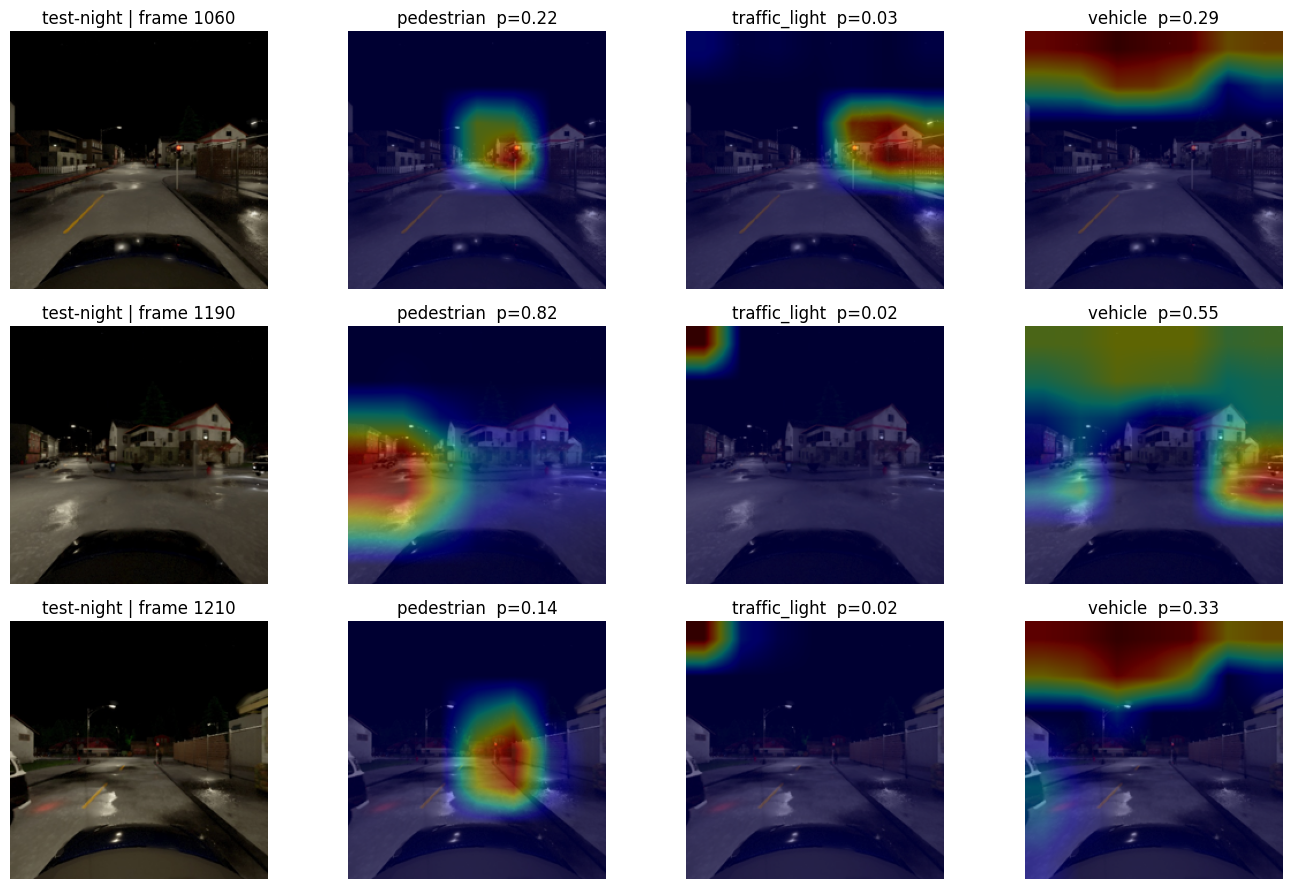

saved gradcam_test-night.png


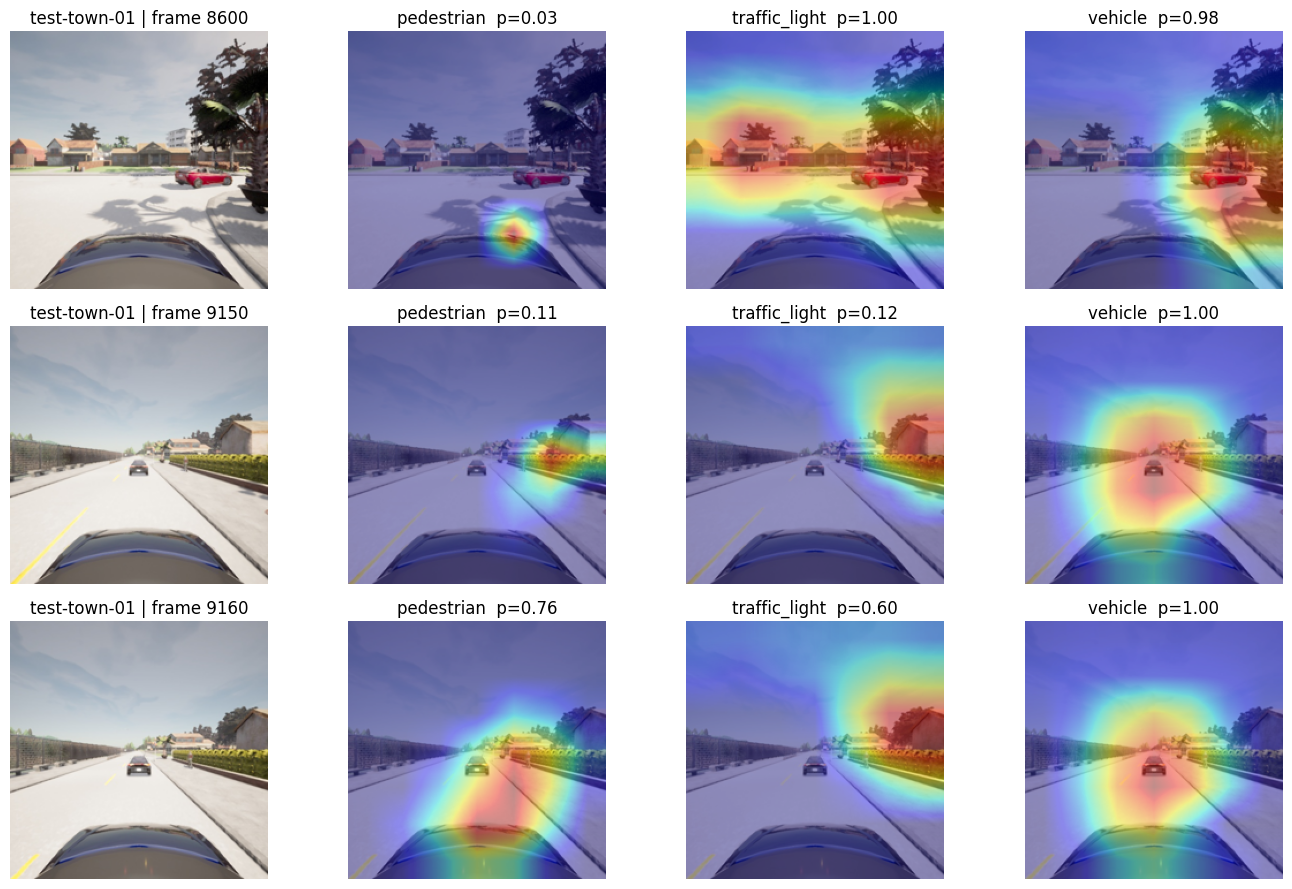

saved gradcam_test-town-01.png


In [7]:
for split in ["test-fog", "test-night", "test-town-01"]:
    show_split(split, n=3)


**Q2. What we saw on the OOD splits.**

**(a) Do the regions still match the objects?**
Not really. On the fog and night splits the vehicle model puts its hottest activation on the top strip of the image regardless of what is in the scene. The traffic light model wanders off to corners or distant areas instead of landing on the actual lights. The pedestrian model occasionally finds a small spot near a real pedestrian (fog frame 1060 is a decent example) but it is way less focused than on the clean test images.

**(b) Any sign of background or shortcut features?**
Yes, and the vehicle model is the obvious one. The heatmap parks itself on the sky strip in pretty much every fog and night frame. In clean Town02 training data that strip is where vehicles tend to appear on the horizon, so the model latched onto it. Take that signal away and the model still looks there because it has nothing better. The traffic light model has a similar problem, leaning on top of frame context rather than the lights themselves.

**(c) How do accuracy and explanation quality change?**
They drop together. Traffic light recall goes from 0.98 on clean test to about 0.003 on night, basically zero, and the heatmaps for night frames are nowhere near the actual lights. Vehicle recall halves on fog (0.90 down to 0.46) and the maps stop pointing at vehicles. Pedestrian was already shaky at 0.45 on clean test and just stays shaky on OOD with the heatmaps wandering around. The takeaway is that bad explanations and bad accuracy show up together, which makes sense because the model is no longer finding the feature it usually relies on.
